In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.arima.model import ARIMA

In [2]:
df = pd.read_csv("C:/inetpub/New excel/HHS_Unaccompanied_Alien_Children_Program.csv")

In [3]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 55.0+ KB


In [5]:
#Clean Date Column
print(df.columns.tolist())

['Date', 'Children apprehended and placed in CBP custody*', 'Children in CBP custody', 'Children transferred out of CBP custody', 'Children in HHS Care', 'Children discharged from HHS Care']


In [6]:
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
df.set_index('Date', inplace=True)

In [8]:
print(df.index)

DatetimeIndex(['2025-12-21', '2025-12-18', '2025-12-17', '2025-12-16',
               '2025-12-15', '2025-12-14', '2025-12-11', '2025-12-10',
               '2025-12-09', '2025-12-08',
               ...
                      'NaT',        'NaT',        'NaT',        'NaT',
                      'NaT',        'NaT',        'NaT',        'NaT',
                      'NaT',        'NaT'],
              dtype='datetime64[ns]', name='Date', length=1170, freq=None)


In [9]:
#Clean "Children in HHS Care"
df['Children in HHS Care'] = (
    df['Children in HHS Care']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)

In [10]:
df['Children in HHS Care'] = pd.to_numeric(
    df['Children in HHS Care'],
    errors='coerce'
)

In [11]:
df['Children in HHS Care'].head()

Date
2025-12-21    2484.0
2025-12-18    2472.0
2025-12-17    2481.0
2025-12-16    2468.0
2025-12-15    2470.0
Name: Children in HHS Care, dtype: float64

In [12]:
#Missing Values
df.isnull().sum()

Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64

In [13]:
df = df.interpolate()

In [14]:
df = df.ffill().bfill()

In [15]:
df.isnull().sum()

Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
dtype: int64

In [19]:
#Exploratory Data Analysis
df.describe()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
count,1170.000000,1170.000000,1170.000000,1170.000000,1170.000000
mean,70.245299,125.919658,92.257265,6255.400000,274.404274
std,64.138328,114.655390,89.154653,2235.387914,161.410400
min,0.000000,7.000000,0.000000,1972.000000,0.000000
25%,33.000000,53.000000,34.000000,6009.250000,154.000000
50%,33.000000,53.000000,34.000000,6566.000000,290.500000
75%,115.000000,220.000000,169.000000,7277.750000,436.000000
max,333.000000,531.000000,440.000000,11516.000000,505.000000


In [20]:
#Correlation
corr = df.corr(numeric_only=True)

corr

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Children apprehended and placed in CBP custody*,1.000000,0.960833,0.912576,0.559894,-0.023089
Children in CBP custody,0.960833,1.000000,0.944407,0.514839,-0.080438
Children transferred out of CBP custody,0.912576,0.944407,1.000000,0.550672,-0.065524
Children in HHS Care,0.559894,0.514839,0.550672,1.000000,0.646047
Children discharged from HHS Care,-0.023089,-0.080438,-0.065524,0.646047,1.000000


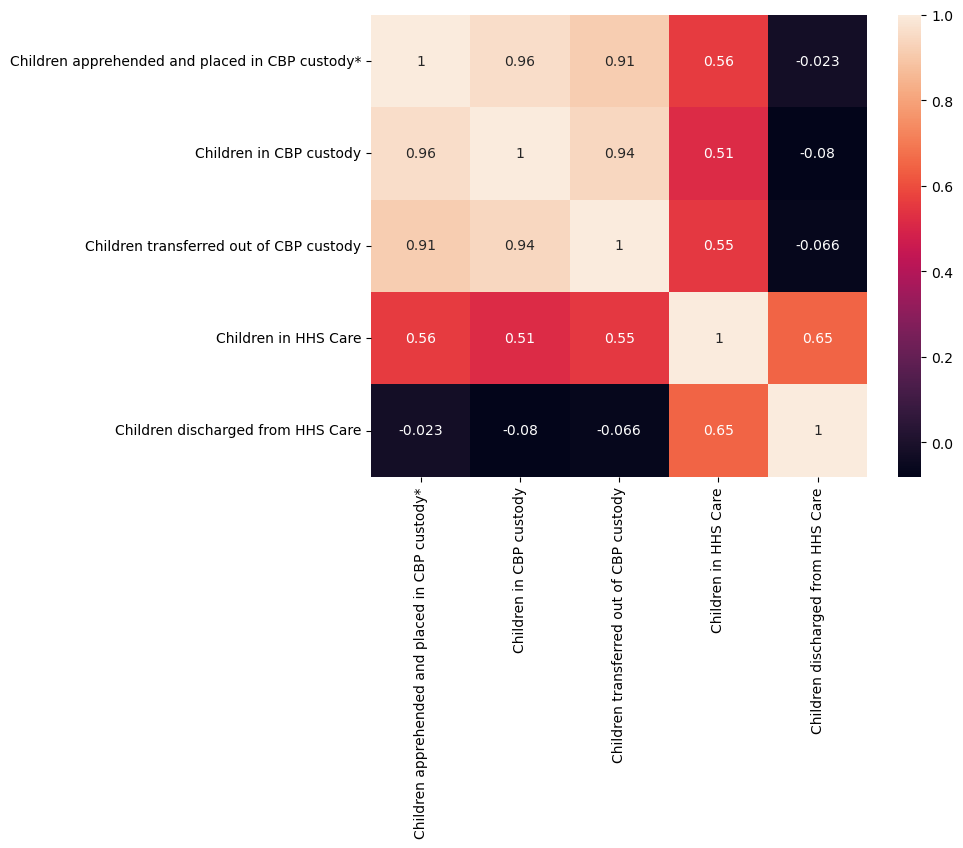

In [21]:
#heatmap
plt.figure(figsize = (8,6))

sns.heatmap(
    corr, 
    annot = True
)

plt.show()

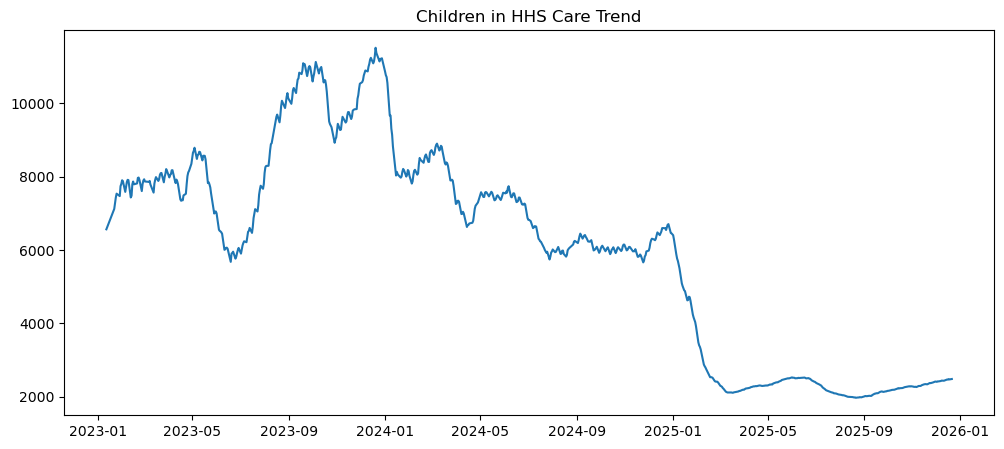

In [22]:
#HHs trend
plt.figure(figsize=(12,5))

plt.plot(df['Children in HHS Care'])

plt.title(
    "Children in HHS Care Trend"
)

plt.show()

In [23]:
#Feature Engineering
df['lag1'] = (
    df['Children in HHS Care']
    .shift(1)
)

df['lag7'] = (
    df['Children in HHS Care']
    .shift(7)
)

df['lag14'] = (
    df['Children in HHS Care']
    .shift(14)
)

In [24]:
#Rolling Means
df['rolling7'] = (
    df['Children in HHS Care']
    .rolling(7)
    .mean()
)

df['rolling14'] = (
    df['Children in HHS Care']
    .rolling(14)
    .mean()
)

In [25]:
#Net Pressure
df['Net_Pressure'] = (
    df['Children transferred out of CBP custody']
    -
    df['Children discharged from HHS Care']
)

In [26]:
#Calendar Features
df['month'] = df.index.month

df['dayofweek'] = df.index.dayofweek

In [27]:
#Remove NaN Generated by Shift
df.dropna(inplace=True)

In [28]:
df.isnull().sum()

Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
lag1                                               0
lag7                                               0
lag14                                              0
rolling7                                           0
rolling14                                          0
Net_Pressure                                       0
month                                              0
dayofweek                                          0
dtype: int64

In [32]:
#Train Test Split
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]

test = df.iloc[train_size:]

In [33]:
#Feature List
features = [
    'lag1',
    'lag7',
    'lag14',
    'rolling7',
    'rolling14',
    'Net_Pressure',
    'month',
    'dayofweek'
]

In [34]:
#Create X and Y
X_train = train[features]

y_train = train[
    'Children in HHS Care'
]

X_test = test[features]

y_test = test[
    'Children in HHS Care'
]

In [36]:
#Random Forest
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


In [37]:
#Gradient Boosting
gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(
    X_train,
    y_train
)

gb_pred = gb.predict(
    X_test
)

In [39]:
#Evaluation
#Random Forest
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

print("RF MAE:", rf_mae)

print("RF RMSE:", rf_rmse)

RF MAE: 147.61070422535204
RF RMSE: 198.17678510950267


In [40]:
#Gradient Boosting
gb_mae = mean_absolute_error(
    y_test,
    gb_pred
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_pred
    )
)

print("GB MAE:", gb_mae)

print("GB RMSE:", gb_rmse)

GB MAE: 148.48286391412233
GB RMSE: 213.2104343771287


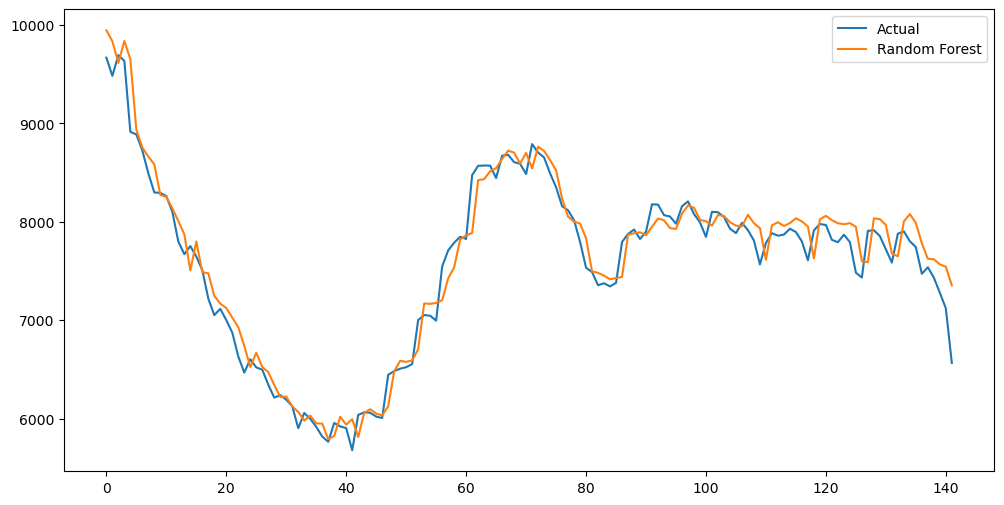

In [41]:
#Forecast Visualization
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    rf_pred,
    label='Random Forest'
)

plt.legend()

plt.show()

In [42]:
#Feature Importance
importance = pd.DataFrame({
    'Feature':features,
    'Importance':
    rf.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
0,lag1,0.334688
3,rolling7,0.208764
2,lag14,0.200408
4,rolling14,0.182008
1,lag7,0.072435
6,month,0.001150
5,Net_Pressure,0.000450
7,dayofweek,0.000098


In [43]:
#Capacity Alert
threshold = (
    df['Children in HHS Care']
    .mean()
)

latest = (
    df['Children in HHS Care']
    .iloc[-1]
)

if latest > threshold:
    print("High Capacity Risk")
else:
    print("Normal Capacity")

High Capacity Risk


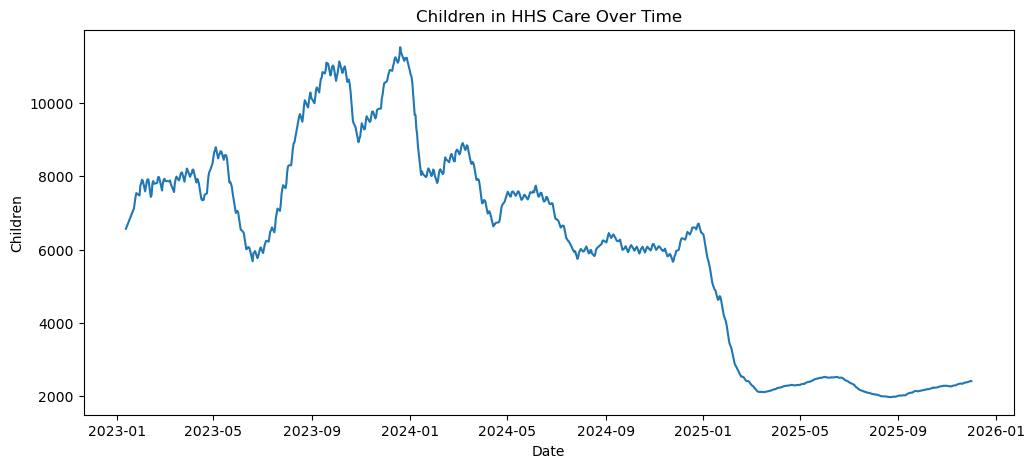

In [44]:
#HHS Care Trend (Line Chart
plt.figure(figsize=(12,5))
plt.plot(df['Children in HHS Care'])
plt.title('Children in HHS Care Over Time')
plt.xlabel('Date')
plt.ylabel('Children')
plt.show()

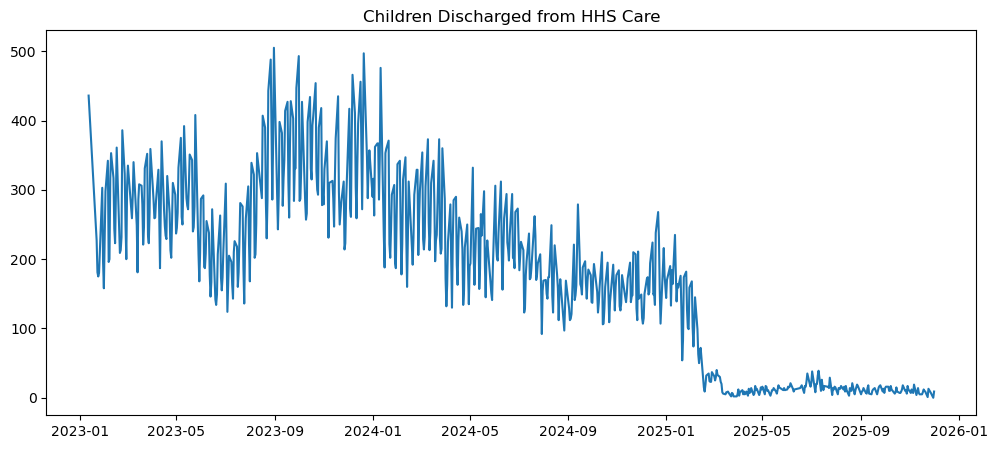

In [45]:
#Discharges Trend
plt.figure(figsize=(12,5))
plt.plot(df['Children discharged from HHS Care'])
plt.title('Children Discharged from HHS Care')
plt.show()

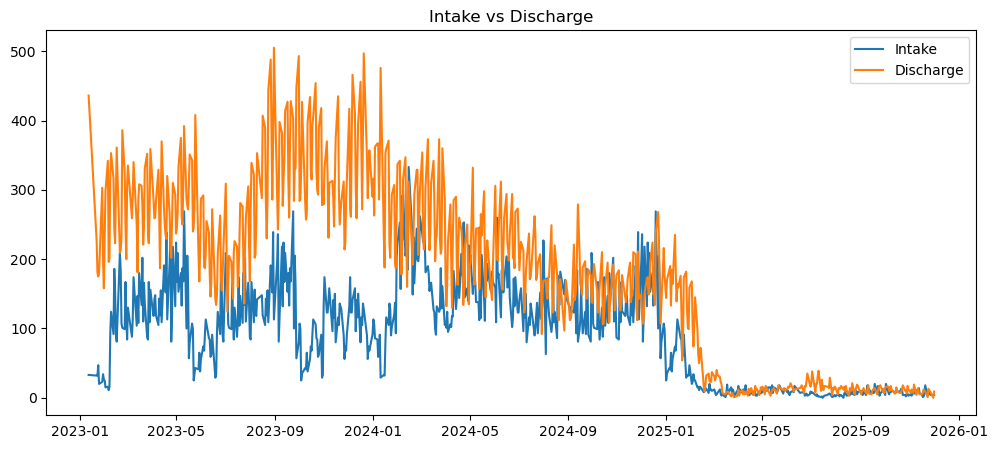

In [46]:
#Intake vs Discharge Comparison
plt.figure(figsize=(12,5))

plt.plot(df['Children apprehended and placed in CBP custody*'],
         label='Intake')

plt.plot(df['Children discharged from HHS Care'],
         label='Discharge')

plt.legend()
plt.title('Intake vs Discharge')
plt.show()

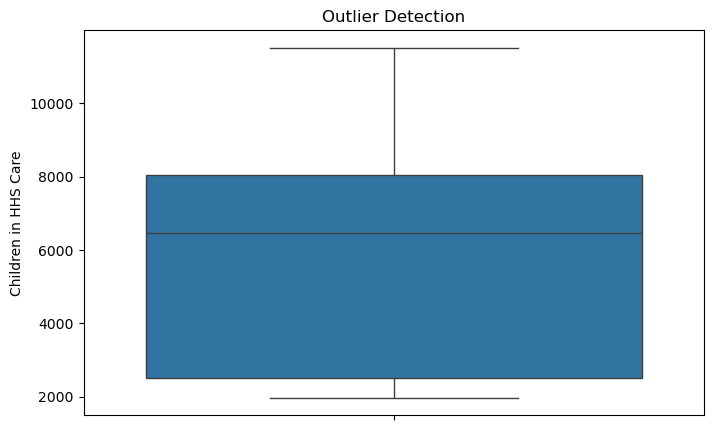

In [47]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df['Children in HHS Care']
)

plt.title('Outlier Detection')
plt.show()

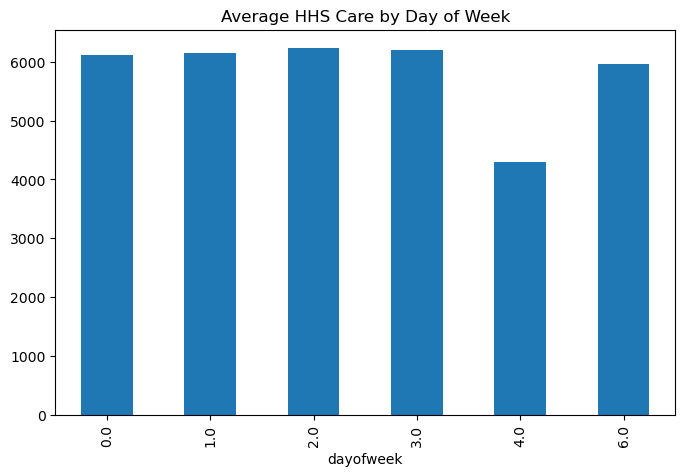

In [48]:
dow = df.groupby('dayofweek')['Children in HHS Care'].mean()

dow.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average HHS Care by Day of Week')
plt.show()

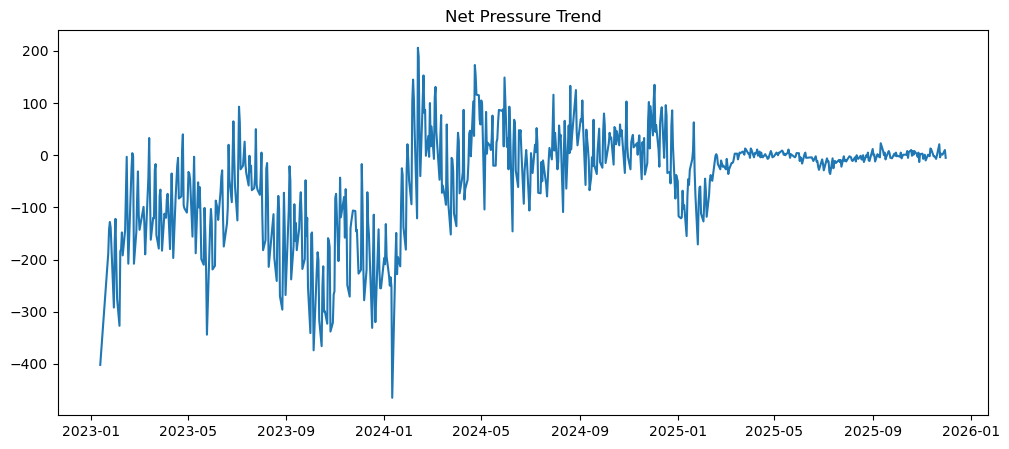

In [49]:
plt.figure(figsize=(12,5))

plt.plot(df['Net_Pressure'])

plt.title('Net Pressure Trend')
plt.show()

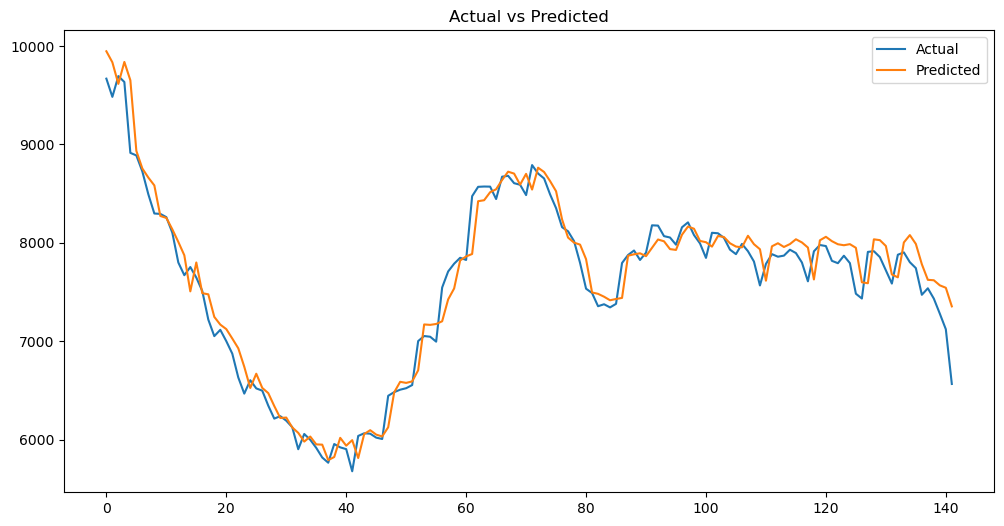

In [51]:
#Actual vs predicted
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    rf_pred,
    label='Predicted'
)

plt.legend()

plt.title('Actual vs Predicted')
plt.show()

In [52]:
df_model = df.copy()

df_model.loc[test.index, 'RF_Prediction'] = rf_pred

In [53]:
df_model.loc[test.index, 'GB_Prediction'] = gb_pred

In [54]:
threshold = df_model['Children in HHS Care'].mean()

df_model['Capacity_Risk'] = np.where(
    df_model['Children in HHS Care'] > threshold,
    'High Risk',
    'Normal'
)

In [55]:
df_export = df_model.reset_index()

In [56]:
df_export.to_excel(
    "HHS_Forecasting_Final.xlsx",
    index=False
)